# Random Forest Classifier
Another try to improve RFC performance by tuning hyperparameters.

Author  : Sameh Ahmed

# Imports and setup

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd


import matplotlib as mpl
import seaborn as sns

# Reset to matplotlib defaults first
mpl.rcParams.update(mpl.rcParamsDefault)

# Theme with explicit white backgrounds (fixes PyCharm dark-theme rendering)
sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "figure.figsize": (12, 5),
        "figure.dpi": 120,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
    },
)
# Project root resolution: walk up until we find the .git directory
cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in (cwd, *cwd.parents) if (p / ".git").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root (no .git directory in parent tree).")

# Paths
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RANDOM_SEED = 42

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

print(f"PROJECT_ROOT      : {PROJECT_ROOT}")
print("Setup complete.")

PROJECT_ROOT      : D:\FHNW-Projects\analyticalProjectProductPricing
Setup complete.


## Section 1: Data Preparation

### 1.1 Load processed data

In [2]:
# 1.1 Load processed data
source_file = "sample.csv"
features: pd.DataFrame = pd.read_csv(DATA_PROCESSED / source_file, sep= "|") # type: ignore

# Diagnostics
features_row_count = len(features)
features_column_count = features.shape[1]

# Integrity check
expected_column_count = 29
assert features_column_count == expected_column_count, (
    f"Expected {expected_column_count} columns, got {features_column_count}"
)

# Display
print(f"Loaded            : {source_file}")
print(f"Rows              : {features_row_count:,}")
print(f"Columns           : {features_column_count}")

Loaded            : sample.csv
Rows              : 200,000
Columns           : 29


### 1.2 Data Exploration

Before any cleaning or feature engineering, the notebook checks the loaded dataset for the things that matter to the model: missing values, dtype consistency, and class balance. The output guides what cleaning steps Section 1.3 applies.

In [3]:
# 1.2 Data Exploration
# Missing values per column
missing_counts = features.isna().sum()
missing_columns = missing_counts[missing_counts > 0]

# Dtypes per column
dtype_summary = features.dtypes

# Target distribution
target_distribution = features["order"].value_counts(normalize=True).sort_index()

# Day range to verify the full window is present
day_min = int(features["day"].min())
day_max = int(features["day"].max())

# Display
print(f"Shape                    : {features.shape}")
print(f"Day range                : {day_min} to {day_max}\n")

print(f"Target distribution (order):")
for label, share in target_distribution.items():
    print(f"Order={label}            : {share:.4f}")

print(f"\nColumns with missing values ({len(missing_columns)} total):")
for column, count in missing_columns.items():
    pct = count / len(features) * 100
    print(f"{column:<40} {count:>7,} ({pct:.1f}%)")

print(f"\ndtypes:")
for column, dtype in dtype_summary.items():
    label = str(column)
    type_name = str(dtype)
    print(f"{label:<40} {type_name}")

Shape                    : (200000, 29)
Day range                : 1 to 92

Target distribution (order):
Order=0            : 0.7441
Order=1            : 0.2559

Columns with missing values (6 total):
competitorPrice                            7,195 (3.6%)
category                                   6,290 (3.1%)
price_diff_competitor                      7,195 (3.6%)
price_ratio_competitor                     7,195 (3.6%)
price_pct_diff_competitor                  7,195 (3.6%)
price_diff_vs_previous_available_day       2,653 (1.3%)

dtypes:
lineID                                   int64
day                                      int64
pid                                      int64
adFlag                                   int64
availability                             int64
competitorPrice                          float64
click                                    int64
basket                                   int64
order                                    int64
price                        

### 1.3 Data Cleaning

Section 1.2 found six columns with missing values. Only one needs explicit handling: `category`, which gets used as a `groupby` key when computing per-category price dispersion in a later section when needed as we plan. Missing categories get filled with the sentinel string `UNKNOWN` so the `groupby` has a key for every row. The other five columns with missing values stay as NaN. RandomForest handles missing numeric values natively at split time (supported since scikit-learn 1.4), so `competitorPrice`, the
three competitor pricing comparison features, and the price lag feature all pass through to the model without imputation.

Note: `price_diff_vs_previous_available_day` is NaN on 2,653 rows where the product was first available and no prior day exists to compute a lag. RandomForest handles this natively at split time. If the model choice ever changes (logistic
 regression, kNN), these columns need imputation first.

In [4]:
# 1.3 Data Cleaning
# Missing category replaced with UNKNOWN sentinel for groupby in feature engineering
category_nan_before = int(features["category"].isna().sum())
features["category"] = features["category"].fillna("UNKNOWN")
category_nan_after = int(features["category"].isna().sum())
unknown_category_count = int((features["category"] == "UNKNOWN").sum())

# Integrity check
assert category_nan_after == 0, f"category still has {category_nan_after} NaN values"

# Display
print(f"Category NaN before fillna : {category_nan_before:,}")
print(f"Category NaN after fillna  : {category_nan_after:,}")
print(f"UNKNOWN category rows      : {unknown_category_count:,}")

Category NaN before fillna : 6,290
Category NaN after fillna  : 0
UNKNOWN category rows      : 6,290


### 1.4 Drop the Early Period
`EDA_Master` Section 5.6 detects a structural break in daily order rate at day 26. The model fits conversion outcomes, so the cutoff matches the conversion break. The early period (days 1 to 25) carries the old conversion regime and gets dropped.
Training data starts at day 26.

In [5]:
# 1.4 Drop the Early Period
early_period_row_count = (features["day"] < 26).sum()
features = features.loc[features["day"] >= 26].reset_index(drop=True)

# Diagnostics
late_period_row_count = len(features)
late_period_day_min = int(features["day"].min())
late_period_day_max = int(features["day"].max())
late_period_order_rate = float(features["order"].mean())

# Integrity checks
assert late_period_day_min == 26, (
    f"Expected min day 26 after filter, got {late_period_day_min}"
)
assert late_period_day_max == 92, (
    f"Expected max day 92, got {late_period_day_max}"
)

# Display
print(f"Early period rows dropped : {early_period_row_count:,}")
print(f"Late period rows kept     : {late_period_row_count:,}")
print(f"Day range                 : {late_period_day_min} to {late_period_day_max}")
print(f"Order rate                : {late_period_order_rate:.4f}")

Early period rows dropped : 37,856
Late period rows kept     : 162,144
Day range                 : 26 to 92
Order rate                : 0.2291


### 1.5 Feature Extraction

Two features get derived in the modeling notebook rather than in the prep script:

- `weekday` from `day`, capturing the weekly seasonality.
- `price_over_rrp` as `price / rrp`, capturing the pricing position signal.

These derivations stay in the modeling notebook, so the prep script remains untouched. The prep script can adopt them later if the lift justifies it.

In [6]:
# 1.5 Feature Extraction
# Weekday position in the 7-day cycle
features["weekday"] = ((features["day"] - 1) % 7).astype("string")

# Price-to-rrp ratio
features["price_over_rrp"] = features["price"] / features["rrp"]

# Diagnostics
weekday_levels = features["weekday"].nunique()
price_over_rrp_nan = int(features["price_over_rrp"].isna().sum())

# Integrity checks
assert weekday_levels == 7, f"Expected 7 weekday levels, got {weekday_levels}"
assert price_over_rrp_nan == 0, f"price_over_rrp has {price_over_rrp_nan} NaN values"

# Display
print(f"Weekday levels                       : {weekday_levels}")
print(f"Price_over_rrp NaN count             : {price_over_rrp_nan}")
print(f"Final column count after derivations : {features.shape[1]}")

Weekday levels                       : 7
Price_over_rrp NaN count             : 0
Final column count after derivations : 31


### 1.6 Stratified Train/Test Split

The split is 80/20, stratified on `order`, with `random_state=RANDOM_SEED` for reproducibility. The test set is held out and not used again until the final evaluation at the end of this notebook. All tuning, calibration, and threshold selection in the intervening
 sections operate on training data via internal cross-validation.

14 columns get dropped from the model input:

- `order` is the target.
- `lineID` is a row identifier with no predictive signal.
- `pid` is the product identifier; per-product effects are absorbed into the target-encoded category, manufacturer, and group columns.
- `click` and `basket` are mutually exclusive with `order` at row level and would leak the target.
- `revenue` is a function of price and order, and would leak the target.
- `rrp` and `competitorPrice` correlate above 0.94 with `price`. Their information enters the model through the derived ratios.
- `unit` provides limited signal beyond what `category` and `pharmForm` already capture.
- `is_post_shift_day` becomes redundant after the day-26 filter.

What remains is 21 features.

In [7]:
# 1.6 Stratified train/test split
from sklearn.model_selection import train_test_split

# Indices for downstream slicing without re-splitting
train_indices, test_indices = train_test_split(
    features.index,
    test_size=0.20,
    stratify=features["order"],
    random_state=RANDOM_SEED,
)
# Feature columns to use for modeling
# Excludes target, identifiers, leakage-prone columns, and non-feature columns
non_feature_columns = [
    "order",
    "lineID",
    "pid",
    "click",
    "basket",
    "revenue",
    "rrp",
    "competitorPrice",
    "unit",
    "is_post_shift_day",
]
feature_columns = [col for col in features.columns if col not in non_feature_columns]

print(f"Feature columns ({len(feature_columns)}):")
for column in feature_columns:
    print(f"{column}")

# Train and test partitions
X_train = features.loc[train_indices, feature_columns].reset_index(drop=True)
X_test = features.loc[test_indices, feature_columns].reset_index(drop=True)
y_train = features.loc[train_indices, "order"].reset_index(drop=True)
y_test = features.loc[test_indices, "order"].reset_index(drop=True)

# Diagnostics
train_row_count = len(X_train)
test_row_count = len(X_test)
train_order_rate = float(y_train.mean())
test_order_rate = float(y_test.mean())

# Integrity checks
assert train_row_count + test_row_count == len(features), (
    f"Train + test do not sum to total"
)
assert abs(train_order_rate - test_order_rate) < 0.001, (
    f"Stratification drift: train {train_order_rate:.4f}, test {test_order_rate:.4f}"
)

# Display
print(f"\nTrain order rate  : {train_order_rate:.4f}")
print(f"Test order rate   : {test_order_rate:.4f}")
print(f"X_train Shape     : {X_train.shape}")
print(f"X_test Shape      : {X_test.shape}")

Feature columns (21):
day
adFlag
availability
price
manufacturer
group
content
pharmForm
genericProduct
salesIndex
category
has_competitor
campaignIndex_A
campaignIndex_B
campaignIndex_C
price_diff_competitor
price_ratio_competitor
price_pct_diff_competitor
price_diff_vs_previous_available_day
weekday
price_over_rrp

Train order rate  : 0.2291
Test order rate   : 0.2291
X_train Shape     : (129715, 21)
X_test Shape      : (32429, 21)


In [8]:
# 1.7 dtype summary for downstream pipeline routing
print("Feature columns and dtypes:")
for column in feature_columns:
    print(f"{column:<40} {str(X_train[column].dtype)}")

Feature columns and dtypes:
day                                      int64
adFlag                                   int64
availability                             int64
price                                    float64
manufacturer                             str
group                                    str
content                                  float64
pharmForm                                str
genericProduct                           int64
salesIndex                               int64
category                                 str
has_competitor                           int64
campaignIndex_A                          int64
campaignIndex_B                          int64
campaignIndex_C                          int64
price_diff_competitor                    float64
price_ratio_competitor                   float64
price_pct_diff_competitor                float64
price_diff_vs_previous_available_day     float64
weekday                                  string
price_over_rrp             

### 1.8 Cast Categorical to String

Four identifier columns arrive as `str` dtype rather than pandas `string`. The encoders treat both correctly in practice, but uniformity matters: a `df.dtypes` audit reads cleanly, and downstream cells that filter columns by dtype behave
predictably. The three high-cardinality target-encoded columns (`category`, `manufacturer`, `group`) and the low-cardinality one-hot column (`pharmForm`) all get cast to `string`. The `weekday` column is already `string` from Section 1.5.

In [9]:
# 1.8 Cast categorical columns to string dtype for uniformity
categorical_columns = ["category", "manufacturer", "group", "pharmForm"]
for column in categorical_columns:
    X_train[column] = X_train[column].astype("string")
    X_test[column] = X_test[column].astype("string")

# Confirmation
print("dtypes after categorical cast:\n")
for column in categorical_columns:
    column_label = str(column)
    column_dtype = str(X_train[column].dtype)
    print(f"{column_label:<20} dtype: {column_dtype}")

dtypes after categorical cast:

category             dtype: string
manufacturer         dtype: string
group                dtype: string
pharmForm            dtype: string


## Section 2: Preprocessing Pipeline and Model

### 2.1 ColumnTransformer

Three branches route the 21 features through different transformations:

- **16 numeric columns** pass through unchanged. RandomForest handles missing values natively at split time (as mentioned in scikit-learn 1.8 documentation).
- **2 low-cardinality categorical** go through OneHotEncoder. With `min_frequency=10`, levels with fewer than 10 training rows collapse into a shared "infrequent" bucket per-feature, protecting against overfitting on singletons in the long tail of `pharmForm`.
- **3 high-cardinality categorical** go through TargetEncoder with 5-fold inner cross-fitting. The cross-fitting prevents leakage by computing each fold's encoded values from the other four folds' targets only. `smooth='auto'` balances per-level signal against the global baseline using an empirical Bayes estimator.

In [10]:
# 2.1 ColumnTransformer with three branches
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder

# Numeric columns pass through unchanged; RandomForest handles NaN natively
numeric_columns = [
    "day",
    "adFlag",
    "availability",
    "price",
    "has_competitor",
    "genericProduct",
    "salesIndex",
    "campaignIndex_A",
    "campaignIndex_B",
    "campaignIndex_C",
    "content",
    "price_diff_competitor",
    "price_ratio_competitor",
    "price_pct_diff_competitor",
    "price_diff_vs_previous_available_day",
    "price_over_rrp",
]

# Low-cardinality categorical get one-hot encoded; each level becomes its own binary column
low_cardinality_columns = [
    "pharmForm",
    "weekday",
]

# High-cardinality categorical get target encoded; each column collapses to one numeric mean per level
high_cardinality_columns = [
    "category",
    "manufacturer",
    "group",
]

one_hot_encoder = OneHotEncoder(
    # Unseen levels at predict time route to the infrequent bucket instead of raising an error
    handle_unknown="infrequent_if_exist",
    # Levels with fewer than 10 training rows collapse into one shared infrequent column per feature
    min_frequency=10,
    # Dense numpy array; trees do not benefit from sparse output
    sparse_output=False,
    # Half the memory of float64; binary 0/1 values do not need higher precision
    dtype=np.float32,
)

target_encoder = TargetEncoder(
    # Explicit because y is binary 0/1; default "auto" infers from y
    target_type="binary",
    # Empirical Bayes smoothing balances per-level signal against the global mean
    smooth="auto",
    # 5-fold inner cross-fitting prevents leakage from each row's target into its own encoded value
    cv=5,
    # Shuffle before splitting; random_state ties to the project seed for reproducibility
    shuffle=True,
    random_state=RANDOM_SEED,
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_columns),
        ("one_hot", one_hot_encoder, low_cardinality_columns),
        ("target", target_encoder, high_cardinality_columns),
    ],
    # Drop any column not listed in the three branches; defensive against accidental passthrough
    remainder="drop",
    # Output names drop the source-branch prefix; cleaner downstream feature importance reporting
    verbose_feature_names_out=False,
)

# Diagnostics
total_routed = len(numeric_columns) + len(low_cardinality_columns) + len(high_cardinality_columns)

# Integrity check
assert total_routed == 21, f"Expected 21 columns routed, got {total_routed}"

# Display
print(f"Numeric (passthrough)        : {len(numeric_columns)} columns")
print(f"One-Hot (low cardinality)    : {len(low_cardinality_columns)} columns")
print(f"Target encoder (high card.)  : {len(high_cardinality_columns)} columns")
print(f"Total routed                 : {total_routed}\n")
print("Preprocessor branches:")
for name, transformer, columns in preprocessor.transformers:
    transformer_label = "passthrough" if transformer == "passthrough" else type(transformer).__name__
    print(f"\n  [{name}] {transformer_label}:")
    for column in columns:
        print(f"    - {column}")

Numeric (passthrough)        : 16 columns
One-Hot (low cardinality)    : 2 columns
Target encoder (high card.)  : 3 columns
Total routed                 : 21

Preprocessor branches:

  [numeric] passthrough:
    - day
    - adFlag
    - availability
    - price
    - has_competitor
    - genericProduct
    - salesIndex
    - campaignIndex_A
    - campaignIndex_B
    - campaignIndex_C
    - content
    - price_diff_competitor
    - price_ratio_competitor
    - price_pct_diff_competitor
    - price_diff_vs_previous_available_day
    - price_over_rrp

  [one_hot] OneHotEncoder:
    - pharmForm
    - weekday

  [target] TargetEncoder:
    - category
    - manufacturer
    - group


### 2.2 Full Pipeline

The preprocessor wraps with the RandomForestClassifier into a single Pipeline. Cross-validation refits the entire pipeline per-fold, so the TargetEncoder's inner cross-fitting prevents leakage automatically.

The classifier uses defaults except for three settings:

- `class_weight='balanced_subsample'` handles the 23/77 class imbalance (post-day-26 filter) with per-bootstrap reweighting.
- `random_state=RANDOM_SEED` for reproducibility across kernel restarts.
- `n_jobs=-1` parallelizes tree fitting across all CPU cores.

All other hyperparameters stay at library defaults. Tuning happens in Section 4 if cross-validation underperforms 70% AUC.

In [11]:
# 2.2 Full pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# default n_estimators=100 sufficient for stable AUC on this data scale as mentioned in sklearn docs; tuning later if underperforming
random_forest = RandomForestClassifier(
    # Per-bootstrap reweighting for the 23/77 imbalance; preferred over plain "balanced" for RF
    class_weight="balanced_subsample",
    # Reproducibility across kernel restarts and across team members
    random_state=RANDOM_SEED,
    # Parallel tree fitting across all CPU cores
    n_jobs=-1,
)

pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", random_forest),
    ]
)

# Display
print("Pipeline structure:\n")
for step_name, step_estimator in pipeline.steps:
    print(f"{step_name}: {type(step_estimator).__name__}")

Pipeline structure:

preprocess: ColumnTransformer
classifier: RandomForestClassifier


## Section 3: Cross-Validation with Defaults

We train and test the model five times, each time on a different slice of the training data, and average the scores. This gives a more reliable picture of how well the model performs than a single train-test run. Each slice keeps the same 22.91%
order rate, so the model sees a representative mix every time.

We score each run with ROC AUC. AUC measures how well the model ranks customers who order ahead of customers who don't, regardless of how rare orders are in the data. This matters because only 23% of interactions end in an order. Plain accuracy
would be misleading: a lazy model that always predicts "no order" would be right 77% of the time without actually learning anything. AUC sees through that. Precision and recall need us to pick a cut-off, for now we use the defaluts 0.5 threshholds.

Decision rule: if AUC averages below 70%, fine-tunes the model later. If it clears 70%, we keep the current settings.

In [12]:
# 3 Cross-validation with defaults
import time
from sklearn.model_selection import StratifiedKFold, cross_validate

# 5-fold splitter that keeps the 22.91% positive class share in every fold's train and validation portions
cv_strategy = StratifiedKFold(
    # 5 splits balances stable estimates against runtime; more splits means more refits of the full pipeline
    n_splits=5,
    # Shuffle before splitting so fold boundaries do not follow row order
    shuffle=True,
    # Fixed seed makes the fold assignments reproducible across runs
    random_state=RANDOM_SEED,
)

# Track time so we know how long the CV took
cv_start_time = time.time()

# Train and score the pipeline 5 times on different fold splits; returns both ROC AUC and F1 per fold
cv_results = cross_validate(
    # The pipeline gets trained from scratch on each fold's training portion
    pipeline,
    # Training feature matrix; CV splits this into 5-fold variants internally
    X_train,
    # Training target; same row alignment as X_train
    y_train,
    # ROC AUC ranks independently of imbalance; F1 uses default threshold 0.5 here, not yet tuned.
    scoring=["roc_auc", "f1"],
    # The 5-fold splitter defined above
    cv=cv_strategy,
    # Folds run sequentially because RandomForest already uses all CPU cores per fit
    n_jobs=1,
)

cv_elapsed_seconds = time.time() - cv_start_time

# ROC AUC across folds
cv_auc_scores = cv_results["test_roc_auc"]
cv_auc_mean = float(cv_auc_scores.mean())
cv_auc_std = float(cv_auc_scores.std())
cv_auc_min = float(cv_auc_scores.min())
cv_auc_max = float(cv_auc_scores.max())

# F1 across folds; computed at default threshold 0.5, not the tuned threshold from Section 6.2
cv_f1_scores = cv_results["test_f1"]
cv_f1_mean = float(cv_f1_scores.mean())
cv_f1_std = float(cv_f1_scores.std())
cv_f1_min = float(cv_f1_scores.min())
cv_f1_max = float(cv_f1_scores.max())

# 70% AUC is the project's minimum acceptable performance
target_auc = 0.70
# True means skip tuning and proceed to test evaluation; False means run hyperparameter tuning first
target_met = cv_auc_mean >= target_auc

# Display
print(f"Runtime: {cv_elapsed_seconds / 60:.1f} minutes\n")
print(f"{'':20} {'ROC_AUC':>10} {'F1':>10}")
print("ROC AUC and F1 per fold:")
for fold_index, (auc, f1) in enumerate(zip(cv_auc_scores, cv_f1_scores), start=1):
    print(f"fold {fold_index:<15} {auc:>10.4f} {f1:>10.4f}")
print(f"\nROC AUC  mean: {cv_auc_mean:.4f} | std: {cv_auc_std:.4f} | range: {cv_auc_min:.4f}-{cv_auc_max:.4f}")
print(f"\nF1 mean: {cv_f1_mean:.4f} | std: {cv_f1_std:.4f} | range: {cv_f1_min:.4f} - {cv_f1_max:.4f}")
print(f"\nTarget AUC: {target_auc:.2f} | Target met: {target_met}")

Runtime: 0.3 minutes

                        ROC_AUC         F1
ROC AUC and F1 per fold:
fold 1                   0.6541     0.2538
fold 2                   0.6563     0.2495
fold 3                   0.6633     0.2581
fold 4                   0.6490     0.2545
fold 5                   0.6578     0.2585

ROC AUC  mean: 0.6561 | std: 0.0047 | range: 0.6490-0.6633

F1 mean: 0.2549 | std: 0.0033 | range: 0.2495 - 0.2585

Target AUC: 0.70 | Target met: False


## Section 4: Hyperparameter Tuning

Mean CV AUC of 0.6561 fell below the 70% target. We tune two hyperparameters: `max_depth` and `min_samples_leaf`. Both are documented in the scikit-learn 1.8 RandomForestClassifier documentation.

- `max_depth` (default `None`) controls the maximum depth of the tree. With the default, nodes expand until all leaves are pure or until they contain fewer than `min_samples_split` samples. Capping depth limits how complex any individual tree can become.
- `min_samples_leaf` (default `1`) sets the minimum number of training rows required at a leaf node. A split is only considered if both resulting branches will hold at least this many samples. The docs note that increasing this value smooths the model.

The grid is intentionally small (4 combinations), so the tuning round completes in a few minutes on the sample. If the best combination's AUC clears 0.70, we move to Section 5. If not, further tuning before feature engineering.

The grid:
- `max_depth` = {None, 30}
- `min_samples_leaf` = {1, 10}

All other hyperparameters stay at the Section 2.2 defaults.

In [13]:
# 4.1 Hyperparameter tuning with focused grid round 1
from sklearn.model_selection import GridSearchCV

# 4 hyperparameter combinations to test; max_depth caps tree growth, min_samples_leaf forces stable leaf sizes
param_grid = {
    # Tree depth limit; None means unlimited; 30 caps growth at 30 levels
    "classifier__max_depth": [None, 30],
    # Minimum training rows per leaf; 1 allows any split, 10 forces leaves to hold at least 10 events
    "classifier__min_samples_leaf": [1, 10],
}

# GridSearchCV runs the full pipeline (preprocess + classifier) on every (combination, fold) pair
grid_search = GridSearchCV(
    # The unfitted pipeline; GridSearchCV trains it from scratch on every fold
    estimator=pipeline,
    # The 4-combination grid; double underscore syntax targets the classifier step inside the pipeline
    param_grid=param_grid,
    # ROC AUC ranks independently of imbalance; F1 uses default threshold 0.5 and not yet tuned.
    scoring={"roc_auc": "roc_auc", "f1": "f1"},
    # Same fold splitter as Section 3 so the comparison is fair
    cv=cv_strategy,
    # Sequential outer loop; 4 combinations * 5 folds * RandomForest's n_jobs=-1 would oversubscribe CPU cores
    n_jobs=1,
    # Rank combinations by ROC AUC; refit the winner on full X_train
    refit="roc_auc",
    # Capture train scores alongside validation scores; reveals overfit gap per combination
    return_train_score=True,
    # Print progress so the cell isn't silent during the long run
    verbose=1,
)

# Run the grid search; this is the long-running step
tuning_start_time = time.time()
grid_search.fit(X_train, y_train)
tuning_elapsed_seconds = time.time() - tuning_start_time

# Build a results table sorted by rank
results_df = (
    pd.DataFrame(grid_search.cv_results_)
    [["params",
      "mean_train_roc_auc", "mean_test_roc_auc", "std_test_roc_auc",
      "mean_train_f1", "mean_test_f1", "std_test_f1",
      "mean_fit_time",
      "rank_test_roc_auc"]]
    .sort_values("rank_test_roc_auc")
    .reset_index(drop=True)
)

# Diagnostics
best_params = grid_search.best_params_
best_score = grid_search.best_score_
# Mean CV AUC from Section 3's default RandomForest baseline
baseline_score = cv_auc_mean
score_lift = best_score - baseline_score

# Display
print(f"Runtime: {tuning_elapsed_seconds / 60:.1f} minutes\n")
print(f"{'Grid search results (sorted by rank):\n'}")
print(f"{'':40} {'ROC_AUC':>8} {'F1':>8} {'gap_auc':>8} {'fit':>6} {'std_auc':>8}")
for row in results_df.itertuples(index=False):
    params_str = ", ".join(f"{k.replace('classifier__', '')}={v}" for k, v in row.params.items())
    gap_auc = row.mean_train_roc_auc - row.mean_test_roc_auc
    print(f"{params_str:<40} {row.mean_test_roc_auc:>8.4f} {row.mean_test_f1:>8.4f} {gap_auc:>+8.4f} {row.mean_fit_time:>5.1f}s {row.std_test_roc_auc:>8.4f}")
print(f"\nBest combination: {best_params} | AUC: {best_score:.4f} | baseline: {baseline_score:.4f} | lift: {score_lift:+.4f}")
print(f"\nTarget AUC: 0.70 | Target met: {best_score >= 0.70}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Runtime: 1.2 minutes

Grid search results (sorted by rank):

                                          ROC_AUC       F1  gap_auc    fit  std_auc
max_depth=30, min_samples_leaf=10          0.6954   0.4442  +0.0843   2.2s   0.0044
max_depth=None, min_samples_leaf=10        0.6952   0.4425  +0.0883   2.3s   0.0046
max_depth=30, min_samples_leaf=1           0.6715   0.3206  +0.2563   2.5s   0.0030
max_depth=None, min_samples_leaf=1         0.6561   0.2549  +0.2927   2.7s   0.0047

Best combination: {'classifier__max_depth': 30, 'classifier__min_samples_leaf': 10} | AUC: 0.6954 | baseline: 0.6561 | lift: +0.0393

Target AUC: 0.70 | Target met: False


#### 4.1 Tuning Results

The leaf size matters; the depth cap does not.

Setting `min_samples_leaf` from 1 to 10 is the change that helps. With `leaf=1`, the trees memorize the training data (0.94 train AUC) but only score 0.66 on validation; they overfit. With  `leaf=10`, training drops to 0.78 and validation rises to
0.70. The model generalizes better.

`max_depth` made almost no difference at `leaf=10` (0.6954 vs. 0.6952). At this leaf size the tree stops growing for the right reasons before the depth cap kicks in. Best combination: `max_depth=30, min_samples_leaf=10`, validation AUC 0.6954. Lift
 over the default baseline: +0.039. Just below the 0.70 target. Section 4.2 will tune two more parameters. The final fit on full data may close more of the gap.

---

### 4.2 Round 2 Tuning

Round 1 locked `min_samples_leaf=10` because it sharply reduced overfitting (train-validation gap dropped from +0.29 to +0.08). The two leaf-10 results in round 1 (`max_depth=30` and `max_depth=None`) tied within fold-std noise
(0.6954–0.6952 = 0.0002 AUC). `max_depth=30` was the rank-1 winner and carries forward.

With those in place, we tune two more hyperparameters: `max_features` and `n_estimators`. `max_features` tests the sqrt default against two larger fractions; `n_estimators` tests whether scaling beyond 100 trees helps.

The grid is 3 * 3 = 9 combinations:
- `max_features` = {"sqrt", 0.3, 0.5}
- `n_estimators` = {100, 200, 300}

In [14]:
# 4.2 Round 2 tuning with focused grid
# Lock round 1 winner onto the pipeline before round 2


# Pass as an unpacked dict explicitly to supress the SettingWithCopyWarning;
# we know we're modifying the pipeline in place and that's what we want to do
pipeline.set_params(**{
    "classifier__max_depth": 30,
    "classifier__min_samples_leaf": 10,
})

param_grid_round_2 = {
    # Number of features considered per split; "sqrt" is the default, 0.3 and 0.5 increase per-tree information
    "classifier__max_features": ["sqrt", 0.3, 0.5],
    # Ensemble size; 100 is the default, 200 and 300 test the diminishing-returns curve
    "classifier__n_estimators": [100, 200, 300],
}

# Same evaluation setup as Section 4.1 for direct comparability
grid_search_round_2 = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_round_2,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=1,
    refit=True,
    return_train_score=True,
    verbose=1,
)

# Run the round 2 grid search
tuning_round_2_start_time = time.time()
grid_search_round_2.fit(X_train, y_train)
tuning_round_2_elapsed_seconds = time.time() - tuning_round_2_start_time

# Build a results table sorted by rank with timing diagnostics for post-run inspection
results_round_2_df = (
    pd.DataFrame(grid_search_round_2.cv_results_)
    [["params",
      "mean_train_score", "mean_test_score", "std_test_score",
      "mean_fit_time",
      "rank_test_score"]]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

# Diagnostics
best_params_round_2 = grid_search_round_2.best_params_
best_score_round_2 = grid_search_round_2.best_score_
round_1_best_score = grid_search.best_score_
round_2_lift = best_score_round_2 - round_1_best_score

# Display
print(f"Runtime: {tuning_round_2_elapsed_seconds / 60:.1f} minutes\n")
print("Round 2 grid search results (sorted by rank):")
for row in results_round_2_df.itertuples(index=False):
    params_str = " , ".join(f"{k.replace('classifier__', '')}={v}" for k, v in row.params.items())
    overfit_gap = row.mean_train_score - row.mean_test_score
    print(f"{params_str:<40} train_roc_auc: {row.mean_train_score:.4f} | val_roc_auc: {row.mean_test_score:.4f} | gap: {overfit_gap:+.4f} | std: {row.std_test_score:.4f} | fit time: {row.mean_fit_time:.1f}s")
print(f"\nBest combination: {best_params_round_2} | AUC: {best_score_round_2:.4f} | round 1 AUC: {round_1_best_score:.4f} | lift: {round_2_lift:+.4f}")
print(f"\nTarget AUC: 0.70 | Target met: {best_score_round_2 >= 0.70}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Runtime: 6.9 minutes

Round 2 grid search results (sorted by rank):
max_features=sqrt , n_estimators=300     train_roc_auc: 0.7806 | val_roc_auc: 0.6960 | gap: +0.0846 | std: 0.0042 | fit time: 6.4s
max_features=sqrt , n_estimators=200     train_roc_auc: 0.7804 | val_roc_auc: 0.6957 | gap: +0.0846 | std: 0.0043 | fit time: 4.2s
max_features=sqrt , n_estimators=100     train_roc_auc: 0.7796 | val_roc_auc: 0.6954 | gap: +0.0843 | std: 0.0044 | fit time: 2.3s
max_features=0.3 , n_estimators=300      train_roc_auc: 0.8399 | val_roc_auc: 0.6938 | gap: +0.1461 | std: 0.0046 | fit time: 12.4s
max_features=0.3 , n_estimators=200      train_roc_auc: 0.8394 | val_roc_auc: 0.6936 | gap: +0.1458 | std: 0.0046 | fit time: 8.4s
max_features=0.3 , n_estimators=100      train_roc_auc: 0.8379 | val_roc_auc: 0.6927 | gap: +0.1452 | std: 0.0047 | fit time: 4.5s
max_features=0.5 , n_estimators=300      train_roc_auc: 0.8459 | val_roc_auc: 0.6923 

#### 4.2 Tuning Results
More trees help a little; the default `max_features='sqrt'` wins clearly.

The `max_features` choice was decisive. All three `sqrt` combinations beat all three `0.3` and `0.5` combinations, regardless of tree count. Larger `max_features` made each tree more accurate on training data (gap nearly doubled, from +0.08 to
+0.15) but added no validation gain, bigger forests of more correlated trees, no extra signal.

`n_estimators` made almost no difference. Going from 100 to 300 trees added 0.0006 AUC, well inside the fold-std noise of 0.004. The trend is monotonic, so the effect is probably real, but the gain is tiny, and the cost is meaningful (300 trees fit
roughly 2.6 times slower than 100).

Best combination: `max_features='sqrt', n_estimators=300`, validation AUC 0.6960. Lift over round 1: +0.0006. The two rounds together added +0.0399 over the default baseline.

## Section 5: Permutation Feature Importance

In [15]:
# 5.1 Permutation importance
from sklearn.inspection import permutation_importance

# Use the round 2 winner; the model has already been refit on full X_train via refit=True
fitted_pipeline = grid_search_round_2.best_estimator_

# Compute permutation importance on training data
# X can be trained or hold-out documented in Sklearn; permuting on train avoids touching X_test
perm_start_time = time.time()
perm_result = permutation_importance(
    # The fitted pipeline including preprocessor and tuned classifier
    estimator=fitted_pipeline,
    # Permute on training data; the test set stays held out until Section 7
    X=X_train,
    # Same target the pipeline was fit against
    y=y_train,
    # Match the metric used throughout Sections 3 and 4
    scoring="roc_auc",
    # 5 shuffles per feature; gives a mean and std for stability
    n_repeats=5,
    # Sequential to avoid joblib worker spawn failure on Windows + Python 3.14
    n_jobs=1,
    # Reproducible shuffle order
    random_state=RANDOM_SEED,
)
perm_elapsed_seconds = time.time() - perm_start_time

# Build a sorted importance table
importance_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance_mean": perm_result.importances_mean,
        "importance_std": perm_result.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

# Display
print(f"Runtime              : {perm_elapsed_seconds / 60:.1f} minutes\n")
print("Permutation importance (sorted by mean AUC drop):")
print(f"{'feature':<40} {'mean':>8} {'std':>8}")
for _, row in importance_df.iterrows():
    print(f"{row['feature']:<40} {row['importance_mean']:>8.4f} {row['importance_std']:>8.4f}")

Runtime              : 1.4 minutes

Permutation importance (sorted by mean AUC drop):
feature                                      mean      std
group                                      0.0336   0.0003
manufacturer                               0.0325   0.0003
price_over_rrp                             0.0301   0.0003
weekday                                    0.0273   0.0001
pharmForm                                  0.0267   0.0001
category                                   0.0249   0.0002
price                                      0.0231   0.0003
day                                        0.0195   0.0001
price_diff_competitor                      0.0187   0.0002
content                                    0.0185   0.0004
price_ratio_competitor                     0.0177   0.0001
price_pct_diff_competitor                  0.0172   0.0002
salesIndex                                 0.0137   0.0001
adFlag                                     0.0132   0.0001
availability                 

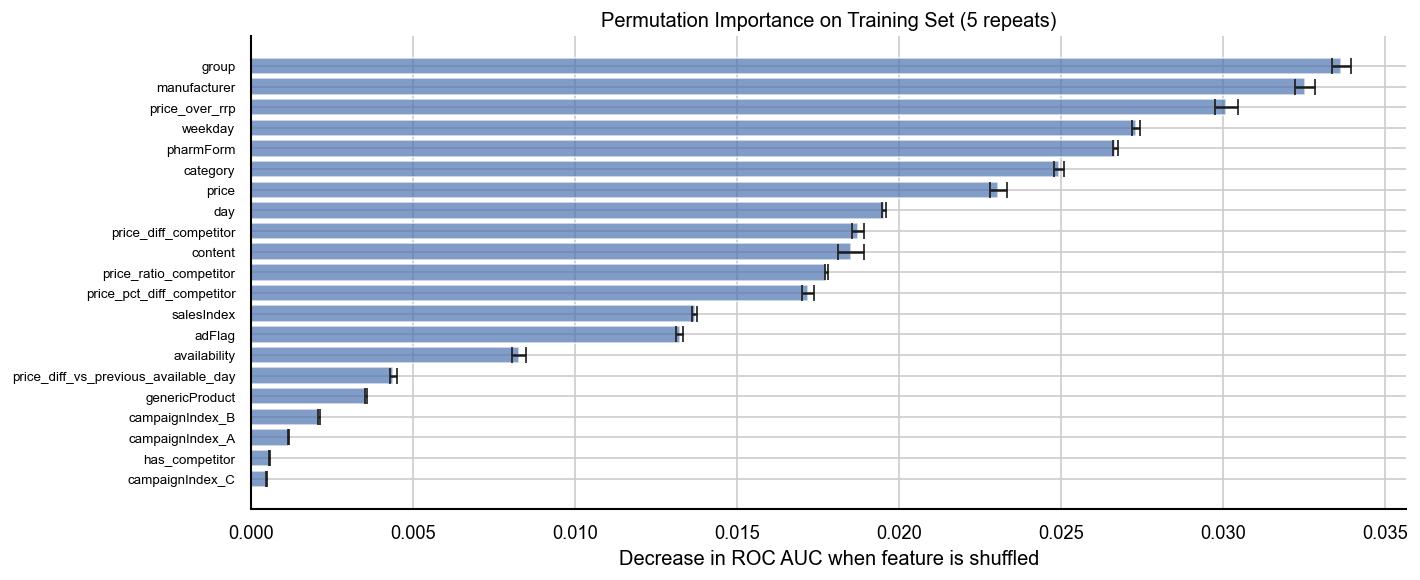

In [16]:
# 5.2 Permutation importance with error bars
import matplotlib.pyplot as plt

# Sort features by mean importance descending (highest at top)
sorted_indices = perm_result.importances_mean.argsort()[::-1]
sorted_features = X_train.columns[sorted_indices]
sorted_means = perm_result.importances_mean[sorted_indices]
sorted_stds = perm_result.importances_std[sorted_indices]

# Horizontal bar plot with error bars
fig, ax = plt.subplots(figsize=(12, 5))
y_pos = np.arange(len(sorted_features))
ax.barh(y_pos, sorted_means, xerr=sorted_stds, align='center', alpha=0.7, capsize=5)
ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_features, fontsize=8)
ax.invert_yaxis()  # Highest importance at top
ax.set_xlabel("Decrease in ROC AUC when feature is shuffled")
ax.set_title("Permutation Importance on Training Set (5 repeats)")
ax.axvline(x=0, color="k", linestyle="--", linewidth=1)
fig.tight_layout()
plt.show()

#### 5.3 Interpretation of Permutation Importance

Permutation importance ranks features by how much shuffling each one costs the model in validation AUC. The pattern splits into three tiers as shown in the table and bar plot above. That suggest that who makes the product, what category it sits in, and how it's priced relative to RRP are the three things that move conversion. The day of the week and the pharmaceutical form also matter. The competitor pricing features have a meaningful but smaller effect. The price lag feature has a small effect, and the promotional campaign features have negligible effect.

---

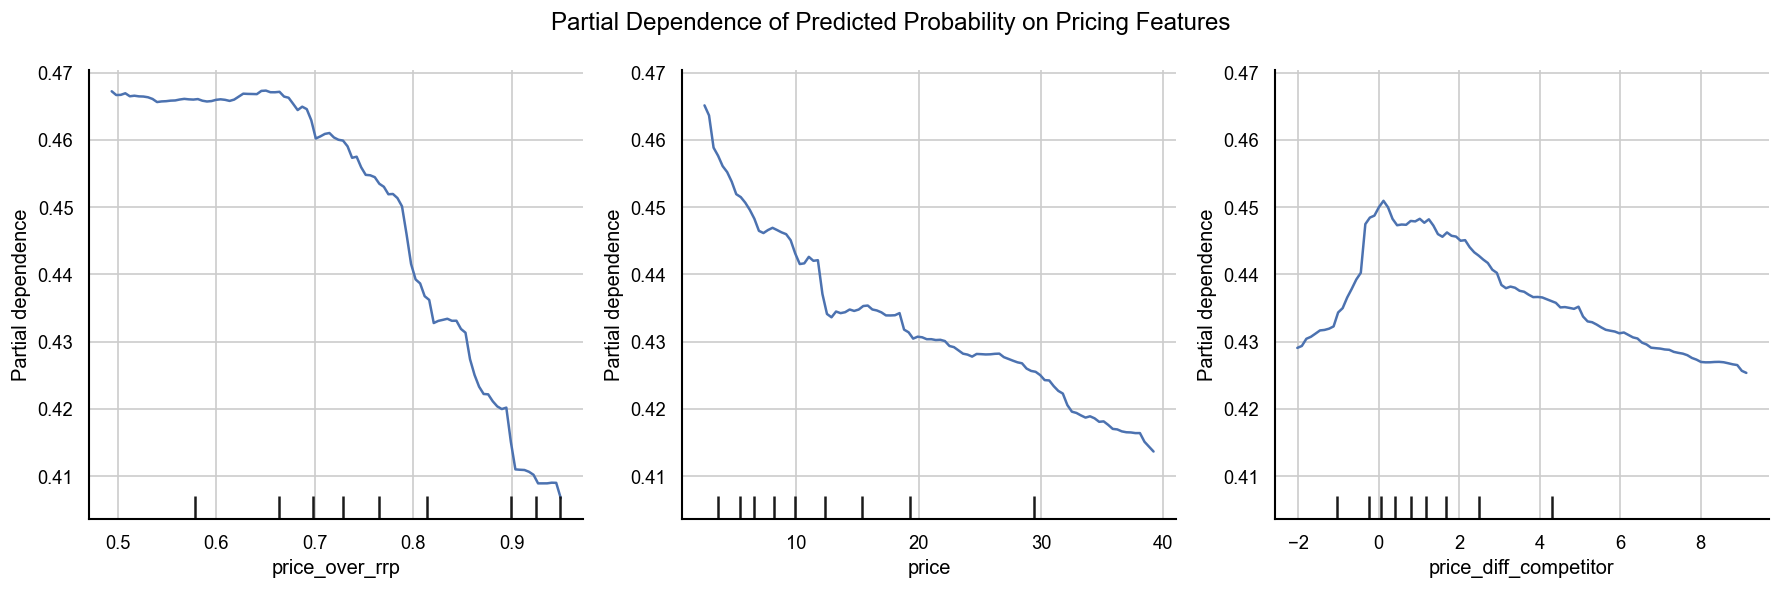

In [17]:
# 5.4 Partial dependence plot for price_over_rrp, price, price_diff_competitor
from sklearn.inspection import PartialDependenceDisplay


# Use the round 2 winner; the model has already been refit on full X_train via refit=True
# Partial dependence plot for the price_over_rrp feature
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
PartialDependenceDisplay.from_estimator(
    estimator=fitted_pipeline,
    X=X_train,
    features=["price_over_rrp", "price", "price_diff_competitor"],
    kind="average",
    ax=ax,
)
fig.suptitle("Partial Dependence of Predicted Probability on Pricing Features")
plt.tight_layout()
plt.show()

#### 5.4 Interpretation of Partial Dependence Plots

> NOTE: The text moved to the documentation paper.

---

## Section 6: Final Evaluation with Calibration and Threshold Tuning

This section produces the final model and evaluates it on `X_test` for the first and only time in the notebook. Three pieces land here:
probability calibration, decision-threshold tuning, and test-set diagnostics.

### 6.1 Calibration

The base pipeline produces probability scores via `predict_proba`, but those probabilities are systematically off. The training distribution is
23/77 positive/negative, and `class_weight='balanced_subsample'` reweights each bootstrap sample toward 50/50 to help the trees discriminate.
The side effect is that the model's probability outputs no longer match real-world frequencies; predicted probabilities sit higher than actual
order rates across most of the range.

`CalibratedClassifierCV` fixes this with isotonic regression. The wrapper does 5-fold cross-validation: for each fold, it fits a copy of the base pipeline on the training portion and learns a per-fold calibration map on the validation portion. At prediction time, the five calibrated probability estimates are averaged. Because each calibration map is learned on data that corresponding base estimator did not see, calibration introduces no leakage.

The scikit-learn documentation cautions against isotonic with fewer than 1000 calibration samples; with 129,715 training rows split into 5
folds, every calibration map fits on approx. 26,000 rows, comfortably above the threshold.

In [18]:
# 6.1 Calibration with isotonic regression and 5-fold cross-fitting
from sklearn.calibration import CalibratedClassifierCV

# Wrap the locked pipeline; the calibrator handles the 5 inner refits
calibrated_pipeline = CalibratedClassifierCV(
    # The unfitted pipeline; CalibratedClassifierCV refits it on each fold
    estimator=pipeline,
    # Non-parametric calibration; flexible shape, safe at this data scale
    method="isotonic",
    # 5-fold inner CV; each fold trains on 4 folds and calibrates on the 5th
    cv=5,
    # Sequential outer loop; RandomForest's n_jobs=-1 saturates cores per fit
    n_jobs=1,
)

# Fit the calibrator; this triggers 5 base-pipeline fits
calibration_start_time = time.time()
calibrated_pipeline.fit(X_train, y_train)
calibration_elapsed_seconds = time.time() - calibration_start_time

# Display
print(f"Runtime              : {calibration_elapsed_seconds / 60:.1f} minutes")
print(f"Calibrators fitted   : {len(calibrated_pipeline.calibrated_classifiers_)}")
print(f"Calibration method   : {calibrated_pipeline.method}")

Runtime              : 0.2 minutes
Calibrators fitted   : 5
Calibration method   : isotonic


### 6.2 Threshold Tuning

The calibrated probabilities from Section 6.1 still need a decision threshold to convert to yes/no predictions. The default 0.5 cutoff is rarely
optimal for imbalanced classification at 23/77, predicting positive only when probability exceeds 0.5 is too conservative, missing many true orders.

`TunedThresholdClassifierCV` finds the threshold that maximizes a chosen metric via cross-validation. We optimize for F1, the harmonic mean of
precision and recall, because the project values both correct positive predictions (precision) and not missing real orders (recall) roughly
equally.

The wrapper does 5-fold CV on `X_train`: for each fold, it fits the calibrated pipeline on 4 folds and evaluates F1 across 100 candidate
thresholds on the 5th fold. The best threshold is averaged across folds. Because the tuning happens entirely on training data via an internal CV, the test set stays untouched until Section 6.3.

In [19]:
# 6.2 Threshold tuning via 5-fold cross-validation on training data
from sklearn.model_selection import TunedThresholdClassifierCV

# Wrap the calibrated pipeline; tuner handles the 5 inner refits and threshold sweep
tuned_pipeline = TunedThresholdClassifierCV(
    # The calibrated pipeline from Section 6.1; tuner clones and refits per fold
    estimator=calibrated_pipeline,
    # F1 balances precision and recall; appropriate for the 23/77 imbalance
    scoring="f1",
    # Sweep 100 candidate thresholds across the predicted-probability range
    thresholds=100,
    # 5-fold inner CV; consistent with Sections 3, 4, and 6.1
    cv=5,
    # Refit on full training data after picking the threshold
    refit=True,
    # Keep per-fold scores for the F1-by-threshold plot in Section 6.5
    store_cv_results=True,
    # Sequential outer loop to avoid CPU oversubscription
    n_jobs=1,
    # Reproducibility across runs
    random_state=RANDOM_SEED,
)

# Fit the tuner; this triggers 5 calibrator fits, each with 5 inner base-pipeline fits
tuning_start_time = time.time()
tuned_pipeline.fit(X_train, y_train)
tuning_elapsed_seconds = time.time() - tuning_start_time

# Diagnostics
best_threshold = tuned_pipeline.best_threshold_
best_score = tuned_pipeline.best_score_

# Display
print(f"Runtime: {tuning_elapsed_seconds / 60:.1f} minutes | best threshold: {best_threshold:.4f} | best F1: {best_score:.4f} | thresholds tested: {len(tuned_pipeline.cv_results_['thresholds'])} evenly spaced between 0 and 1")

Runtime: 1.1 minutes | best threshold: 0.2306 | best F1: 0.4520 | thresholds tested: 100 evenly spaced between 0 and 1


### 6.3 Final Test and validation Evaluation

This is the only place in the notebook where `X_test` gets used. Every prior section operated on `X_train` via internal cross-validation. The
test set has been held out since Section 1.6 and is now opened once for an honest estimate of generalization performance we hope.

Three families of metrics get reported:

**Discriminative skill (ROC AUC):** the probability that the model ranks a random positive case above a random negative case. Independent of
the chosen threshold and of the class imbalance.

**Probability calibration (Brier score):** the mean squared error between predicted probabilities and observed outcomes. Lower is better. We
compute this for both uncalibrated and calibrated probabilities to confirm that Section 6.1's calibration improved the probability quality,
not just the AUC.

**Decision quality (F1, precision, recall, accuracy):** computed at the tuned threshold from Section 6.2. These describe how well the model
 converts probabilities into classification decisions when the cutoff is at 0.2306.

We also compute training error rate alongside test error rate as a generalization-gap diagnostic. A small gap between the two confirms the
model is not overfitting to the training data.

In [20]:
# 6.3 Final test evaluation
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
)

# Predictions on test set; only place X_test gets touched
# Probabilities for AUC and Brier; class predictions for F1, precision, recall, accuracy
y_test_proba_calibrated = tuned_pipeline.predict_proba(X_test)[:, 1]
y_test_pred = tuned_pipeline.predict(X_test)

# Uncalibrated probabilities for the Brier score comparison
# Use the unwrapped pipeline that was fitted via best_estimator_ in Section 4.2
y_test_proba_uncalibrated = grid_search_round_2.best_estimator_.predict_proba(X_test)[:, 1]

# Train-set predictions for the generalization gap diagnostic
y_train_pred = tuned_pipeline.predict(X_train)

# Discriminative skill
test_auc = roc_auc_score(y_test, y_test_proba_calibrated)

# Probability calibration
test_brier_uncalibrated = brier_score_loss(y_test, y_test_proba_uncalibrated)
test_brier_calibrated = brier_score_loss(y_test, y_test_proba_calibrated)
brier_improvement = test_brier_uncalibrated - test_brier_calibrated

# Decision quality at the tuned threshold
test_f1 = f1_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Generalization gap
train_accuracy = accuracy_score(y_train, y_train_pred)
test_error_rate = 1.0 - test_accuracy
train_error_rate = 1.0 - train_accuracy
generalization_gap = test_error_rate - train_error_rate

# Confusion matrix at the tuned threshold
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

# Display
print(f"Discriminative skill:\nTest AUC: {test_auc:.4f}\n")
print(f"Probability calibration:\nBrier uncalibrated: {test_brier_uncalibrated:.4f} | Brier calibrated: {test_brier_calibrated:.4f} | improvement: {brier_improvement:+.4f}\n")
print(f"Decision quality at threshold {best_threshold:.4f}:\nF1: {test_f1:.4f} | precision: {test_precision:.4f} | recall: {test_recall:.4f} | accuracy: {test_accuracy:.4f}\n")
print(f"Confusion matrix:\nTN: {tn:,} | FP: {fp:,} | FN: {fn:,} | TP: {tp:,}\n")
print(f"Generalization gap:\nTrain error: {train_error_rate:.4f} | Test error: {test_error_rate:.4f} | gap: {generalization_gap:+.4f}")

Discriminative skill:
Test AUC: 0.6962

Probability calibration:
Brier uncalibrated: 0.2092 | Brier calibrated: 0.1614 | improvement: +0.0478

Decision quality at threshold 0.2306:
F1: 0.4526 | precision: 0.3405 | recall: 0.6746 | accuracy: 0.6260

Confusion matrix:
TN: 15,289 | FP: 9,709 | FN: 2,418 | TP: 5,013

Generalization gap:
Train error: 0.3364 | Test error: 0.3740 | gap: +0.0375


#### 6.3 Interpretation of Final Evaluation
The model generalizes cleanly to the held-out test set. Test AUC of 0.6962 sits 0.0002 above the Section 4.2 CV estimate of 0.6960, the cross-validation procedure produced an honest estimate, and the test set confirmed it.

Calibration delivered a meaningful improvement in probability quality. The Brier score dropped from 0.2092 (uncalibrated) to 0.1614 (calibrated), a reduction of 0.0478; roughly 23% relative improvement (0.0478 / 0.2092). Predicted probabilities now track observed order rates more closely, making them usable for any downstream decision that depends on probability magnitudes.

At the tuned threshold of 0.2306, the model achieves a recall of 0.6746, meaning it correctly identifies 67.46% of actual orders. (recall 0.6746 = 5,013 / 7,431, where 7,431 = tp + fn = 5,013 + 2,418), at a precision of 0.3405 (5,013 / 14,722, where 14,722 = tp + fp = 5,013 + 9,709). The F1 of 0.4526 reflects both: the model is recall-heavy by design, flagging broadly to avoid missing real orders at the cost of a higher false-positive rate.

The generalization gap is small. Train error rate is 0.3364 and test error rate is 0.3740. The gap, computed from unrounded values, is +0.0375. This small gap is consistent with the modest +0.0843 train-validation AUC gap observed during round 1 tuning with min_samples_leaf=10, indicating that leaf-size regularization controlled overfitting in the final model. The Brier improvement of 0.0478 reported earlier confirms that the calibration step produced more accurate probability estimates than the uncalibrated model.

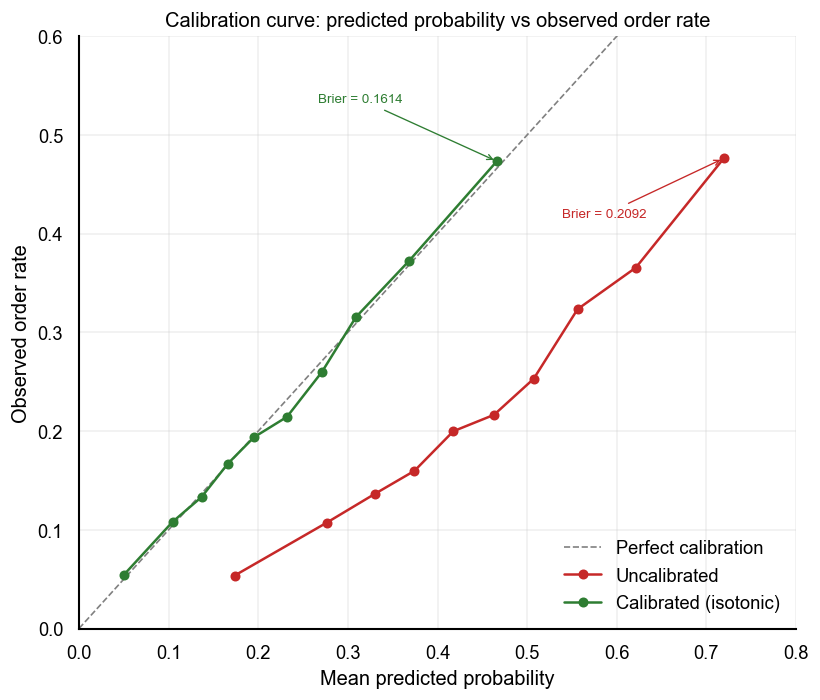

In [21]:
# 6.4 Calibration curve: uncalibrated vs calibrated vs perfect
from sklearn.calibration import calibration_curve

# Uncalibrated probabilities from grid_search_round_2.best_estimator_ (Section 6.3)
prob_true_uncal, prob_pred_uncal = calibration_curve(
    y_test,
    y_test_proba_uncalibrated,
    n_bins=10,
    strategy="quantile",
)

# Calibrated probabilities from tuned_pipeline (Section 6.3)
prob_true_cal, prob_pred_cal = calibration_curve(
    y_test,
    y_test_proba_calibrated,
    n_bins=10,
    strategy="quantile",
)

fig, ax = plt.subplots(figsize=(7, 6))

# Perfect calibration diagonal
ax.plot(
    [0, 1], [0, 1],
    linestyle="--", color="gray", linewidth=1,
    label="Perfect calibration",
)

# Uncalibrated curve
ax.plot(
    prob_pred_uncal, prob_true_uncal,
    marker="o", markersize=5, linewidth=1.5,
    color="#C62828", label="Uncalibrated",
)

# Calibrated curve
ax.plot(
    prob_pred_cal, prob_true_cal,
    marker="o", markersize=5, linewidth=1.5,
    color="#2E7D32", label="Calibrated (isotonic)",
)

# Brier score annotation on uncalibrated curve (last point)
ax.annotate(
    f"Brier = {test_brier_uncalibrated:.4f}",
    xy=(prob_pred_uncal[-1], prob_true_uncal[-1]),
    xytext=(prob_pred_uncal[-1] - 0.18, prob_true_uncal[-1] - 0.06),
    fontsize=8,
    color="#C62828",
    arrowprops=dict(arrowstyle="->", color="#C62828", lw=0.8),
)

# Brier score annotation on calibrated curve (last point)
ax.annotate(
    f"Brier = {test_brier_calibrated:.4f}",
    xy=(prob_pred_cal[-1], prob_true_cal[-1]),
    xytext=(prob_pred_cal[-1] - 0.20, prob_true_cal[-1] + 0.06),
    fontsize=8,
    color="#2E7D32",
    arrowprops=dict(arrowstyle="->", color="#2E7D32", lw=0.8),
)

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed order rate")
ax.set_title("Calibration curve: predicted probability vs observed order rate")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.set_xlim(0, 0.80)
ax.set_ylim(0, 0.60)
fig.tight_layout()
plt.show()

#### 6.4 Interpretation of Calibration Curve

The uncalibrated red curve sits below the diagonal: the model predicts 60% chance of order where the actual rate is closer to 30%. Calibration pulls the green curve onto the diagonal across its full range, dropping the Brier score from 0.2092 to 0.1614 (a 23%
reduction). The calibrated model never predicts above 0.47 on the x-axis, matching the observed order rate of roughly 0.48 in that probability range.

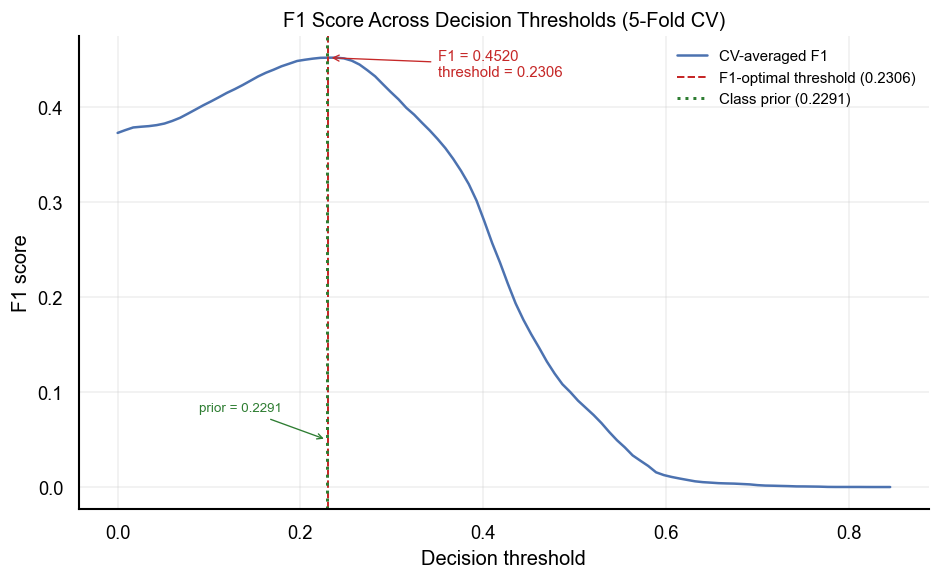

In [22]:
# 6.5 F1-by-threshold plot from TunedThresholdClassifierCV cross-validation results
# cv_results_ holds the threshold sweep from Section 6.2
thresholds = tuned_pipeline.cv_results_["thresholds"]
f1_scores = tuned_pipeline.cv_results_["scores"]

# Class prior from Section 1.6
class_prior = y_train.mean()

# Peak F1 value for annotation
peak_f1 = tuned_pipeline.best_score_
peak_threshold = tuned_pipeline.best_threshold_

fig, ax = plt.subplots(figsize=(8, 5))

# F1 curve
ax.plot(
    thresholds, f1_scores,
    linewidth=1.5, color="#4C72B0",
    label="CV-averaged F1",
)

# F1-optimal threshold vertical line
ax.axvline(
    x=peak_threshold,
    color="#C62828", linestyle="--", linewidth=1.2,
    label=f"F1-optimal threshold ({peak_threshold:.4f})",
)

# Class prior vertical line
ax.axvline(
    x=class_prior,
    color="#2E7D32", linestyle=":", linewidth=1.8,
    label=f"Class prior ({class_prior:.4f})",
)

# Peak annotation moved to the right of the peak, below the title
ax.annotate(
    f"F1 = {peak_f1:.4f}\nthreshold = {peak_threshold:.4f}",
    xy=(peak_threshold, peak_f1),
    xytext=(peak_threshold + 0.12, peak_f1 - 0.02),
    fontsize=9,
    color="#C62828",
    arrowprops=dict(arrowstyle="->", color="#C62828", lw=0.8),
)

# Class prior annotation to separate it visually from the threshold line
ax.annotate(
    f"prior = {class_prior:.4f}",
    xy=(class_prior, 0.05),
    xytext=(class_prior - 0.14, 0.08),
    fontsize=8,
    color="#2E7D32",
    arrowprops=dict(arrowstyle="->", color="#2E7D32", lw=0.8),
)

ax.set_xlabel("Decision threshold")
ax.set_ylabel("F1 score")
ax.set_title("F1 Score Across Decision Thresholds (5-Fold CV)")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

#### 6.5 Interpretation of F1-by-threshold Plot
The F1 score peaks at the F1-optimal threshold (0.2306) and reaches a CV-averaged F1 of 0.4520, matching the value reported in Section 6.2. Between threshold values of roughly 0.18 and 0.28, the curve is flat. Small shifts around 0.2306 cost almost nothing in F1. The chosen threshold sits on a stable plateau, not a knife edge.

Below 0.18, the model flags nearly every row as positive. Recall is high but precision falls, and F1 drops to 0.38 at threshold 0.0. Above 0.28, F1 falls sharply: 0.30 by threshold 0.40, near zero by 0.60, as recall collapses, and the model stops flagging orders entirely.

The two sides of the curve are not symmetric. The left decline is gradual; the right decline is steep. At 23/77 class imbalance, raising the threshold above the class prior (0.2291) rapidly eliminates true positives. There are not enough
positive cases in each score band to maintain recall once the threshold passes the base rate.

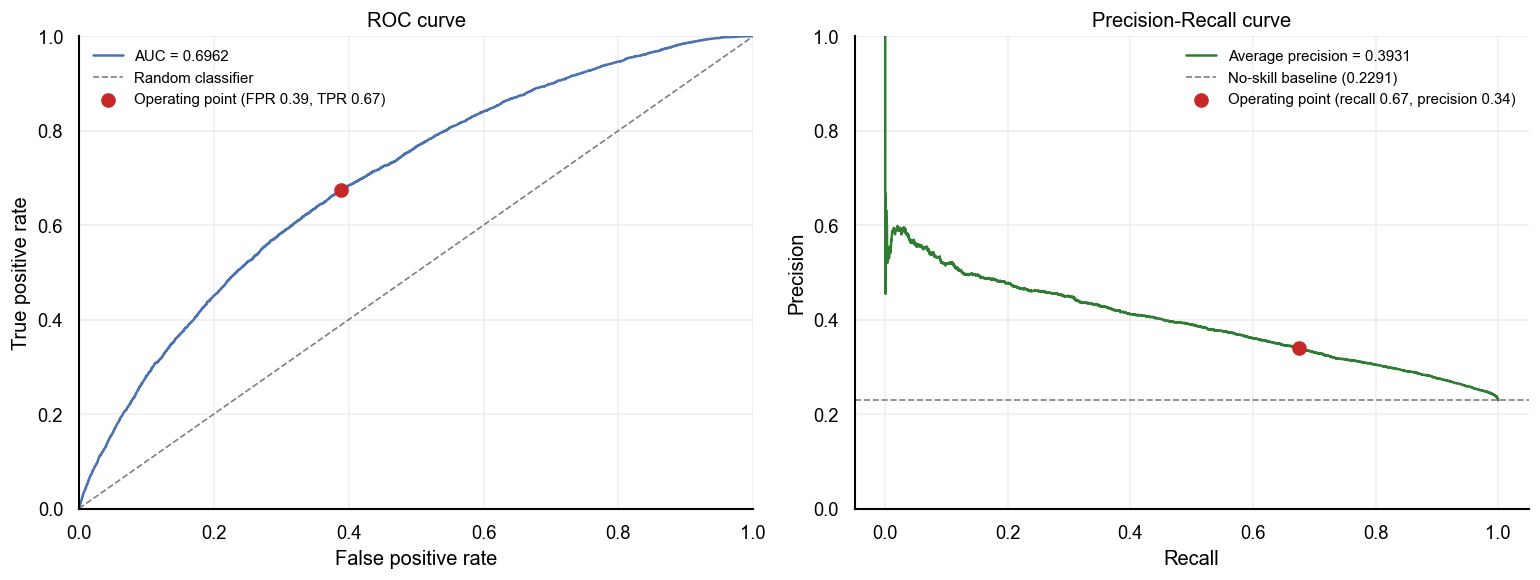

In [23]:
# 6.6 ROC curve and Precision-Recall curve on the held-out test set
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

# ROC curve data from calibrated probabilities (Section 6.3)
fpr, tpr, _ = roc_curve(y_test, y_test_proba_calibrated)

# Precision-Recall curve data
precision_vals, recall_vals, _ = precision_recall_curve(
    y_test, y_test_proba_calibrated
)
average_precision = average_precision_score(y_test, y_test_proba_calibrated)

# Operating point coordinates from Section 6.3 confusion matrix
op_fpr = fp / (fp + tn)
op_tpr = test_recall
op_precision = test_precision
op_recall = test_recall

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
axes[0].plot(fpr, tpr, linewidth=1.5, color="#4C72B0", label=f"AUC = {test_auc:.4f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Random classifier")
axes[0].scatter(
    op_fpr, op_tpr,
    color="#C62828", zorder=5, s=60,
    label=f"Operating point (FPR {op_fpr:.2f}, TPR {op_tpr:.2f})",
)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve")
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Precision-Recall curve
axes[1].plot(recall_vals, precision_vals, linewidth=1.5, color="#2E7D32", label=f"Average precision = {average_precision:.4f}")
axes[1].axhline(
    y=y_test.mean(), linestyle="--", color="gray", linewidth=1,
    label=f"No-skill baseline ({y_test.mean():.4f})",
)
axes[1].scatter(
    op_recall, op_precision,
    color="#C62828", zorder=5, s=60,
    label=f"Operating point (recall {op_recall:.2f}, precision {op_precision:.2f})",
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend(frameon=False, fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1)

fig.tight_layout()
plt.show()

#### 6.6 Interpretation of ROC and Precision-Recall Curves

FPR = FP / (FP + TN)
TPR = TP / (TP + FN) = recall
Precision = TP / (TP + FP)

The ROC curve (left panel) plots the model's true positive rate against its false positive rate across every possible decision threshold. At the tuned threshold of 0.2306, the operating point sits at FPR 0.3884 and TPR 0.6746, derived from the Section 6.3 confusion matrix as follows:

FPR = FP / (FP + TN) = 9,709 / 24,998 = 0.3884
TPR = TP / (TP + FN) = 5,013 / 7,431 = 0.6746

An AUC of 0.6962 means the model assigns a higher probability to a randomly drawn order than to a randomly drawn non-order 69.62% of the time. A model with no skill would score 0.50. The curve's distance from the diagonal reflects that discriminative advantage.

The Precision-Recall curve (right panel) is more informative for this dataset, where orders account for only 22.91% of rows. It shows that at full recall (catching every order), precision falls to the no-skill baseline of 0.2291. As the threshold rises, and the model becomes more selective, precision climbs. At the operating point, precision is 0.3405 and recall is 0.6746:

Precision = TP / (TP + FP) = 5,013 / 14,722 = 0.3405

Average precision of 0.3931 summarises the full curve in one number, the weighted mean of precision at each recall level. For a pharmacy targeting customers likely to order, the PR curve is the right frame: of every 100 rows flagged at the tuned threshold, 34 are actual orders, against a baseline of 23 if the model flagged rows at random.

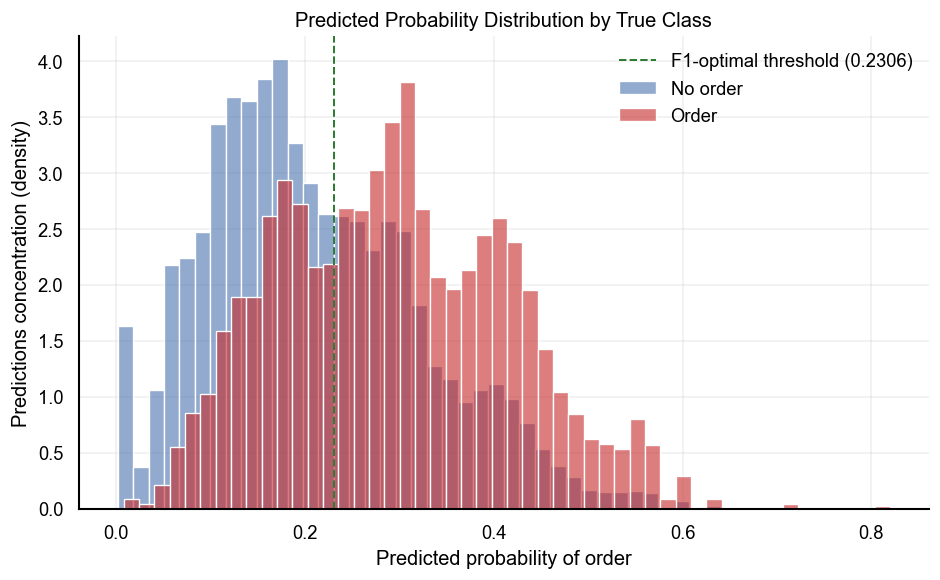

In [24]:
# 6.7 Predicted probability distribution by true class
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    y_test_proba_calibrated[y_test == 0],
    color="#4C72B0", label="No order", stat="density",
    bins=50, alpha=0.6, ax=ax,
)
sns.histplot(
    y_test_proba_calibrated[y_test == 1],
    color="#C62828", label="Order", stat="density",
    bins=50, alpha=0.6, ax=ax,
)

# Tuned threshold vertical line
ax.axvline(
    x=best_threshold,
    color="#2E7D32", linestyle="--", linewidth=1.2,
    label=f"F1-optimal threshold ({best_threshold:.4f})",
)

ax.set_xlabel("Predicted probability of order")
ax.set_ylabel("Predictions concentration (density)")
ax.set_title("Predicted Probability Distribution by True Class")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

#### 6.7 Interpretation of Predicted Probability Distributions

The blue distribution (no order) peaks at low predicted probabilities, roughly between 0.05 and 0.20 on the x-axis. Most non-ordering customers received low scores from the model. The red distribution (order) is broader and shifted right, peaking around 0.25 to 0.40, meaning ordering customers
tend to receive higher scores.

Both distributions overlap heavily in the middle region. In this range, the model assigned similar probabilities to customers who ordered and customers who did not. This is where most errors originate, and no threshold placement can eliminate them entirely.
The F1-optimal threshold (0.2306, green dashed line) is the decision boundary. Customers to its right get predicted as orders; customers to its left get predicted as no order. The threshold sits near the point where the two distributions cross, balancing false positives against false negatives.

The width of the overlap zone is a direct visual representation of the model's difficulty with this task. A perfect model would show two fully separated distributions with no mixing. The overlap here is consistent with the test AUC of 0.6962, reflecting real but imperfect separation between the two classes. That means, every overlapping region is a zone where the model will make mistakes regardless of where is the threshold. If we draw the threshold line through an overlapping region:
   - The blue bars to the right of the line become false positives.
   - The red bars to the left of the line become false negatives.